# Ejercicio COLMAP — Reconstrucción 3D y comparación con vggt

**Objetivo:** reconstruir un modelo 3D de un objeto a partir de un conjunto de imagenes usando **COLMAP** (Structure-from-Motion clásico) y comparar el resultado con **vggt** (reconstrucción basada en transformers).

## Marco Teórico

### Structure-from-Motion (SfM)

**Structure-from-Motion** es la técnica que, dado un conjunto de imágenes de una misma escena tomadas desde distintos puntos de vista, recupera simultáneamente:

- La **estructura 3D** de la escena (nube de puntos).
- Los **parámetros de cámara** de cada imagen (posición y orientación).

El proceso se basa en la **correspondencia de características** entre imágenes: si el mismo punto 3D $P$ aparece en dos imágenes como $p_1$ y $p_2$, se puede triangular su posición usando los rayos de proyección de ambas cámaras.

### Características SIFT

COLMAP usa **SIFT** (*Scale-Invariant Feature Transform*) para detectar y describir puntos de interés. Cada punto queda representado por un descriptor. Dos imágenes se emparejan buscando descriptores similares mediante distancia euclídea.

### RANSAC

Las correspondencias entre imágenes contienen errores (emparejamientos incorrectos). **RANSAC** (*Random Sample Consensus*) estima la geometría epipolar robustamente: prueba muchas hipótesis con subconjuntos aleatorios de correspondencias y se queda con la que tiene más correspondencias compatibles (*inliers*).

### Pipeline de COLMAP

| Paso | Herramienta | Descripción |
|------|------------|-------------|
| 1 | `feature_extractor` | Detecta y describe puntos SIFT en cada imagen |
| 2 | `exhaustive_matcher` | Empareja características entre todos los pares de imágenes |
| 3 | `mapper` | Reconstrucción incremental: inicializa con un par, añade imágenes una a una |
| 4 | Bundle adjustment | Optimiza simultáneamente poses de cámara y posiciones 3D minimizando el error de reproyección |

### vggt

**vggt** (*Visual Geometry Grounded deep structure from motion*, CVPR 2025 Best Paper) sustituye el pipeline clásico por un **transformer** entrenado con millones de escenas. Dado un conjunto de imágenes, predice directamente las poses de cámara y un mapa de profundidad denso en una sola pasada hacia adelante, sin iteraciones ni RANSAC.

## 1. Extracción de frames del vídeo

Se graba un vídeo rodeando el objeto y se extraen frames a **5 fps**. Así se obtiene suficiente solapamiento entre imágenes consecutivas manteniendo un número manejable.

In [18]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np

VIDEO  = 'peluche-video.mp4'
FRAMES = 'frames'
FPS_OUT = 5

os.makedirs(FRAMES, exist_ok=True)

cap = cv2.VideoCapture(VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
step = int(fps / FPS_OUT)
n, saved = 0, 0

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if n % step == 0:
        cv2.imwrite(f'{FRAMES}/frame_{n:04d}.jpg', frame)
        saved += 1
    n += 1

cap.release()
print(f'Vídeo: {fps:.1f} fps, {n} frames totales')
print(f'Frames extraídos a {FPS_OUT} fps: {saved}')

Vídeo: 29.0 fps, 900 frames totales
Frames extraídos a 5 fps: 180


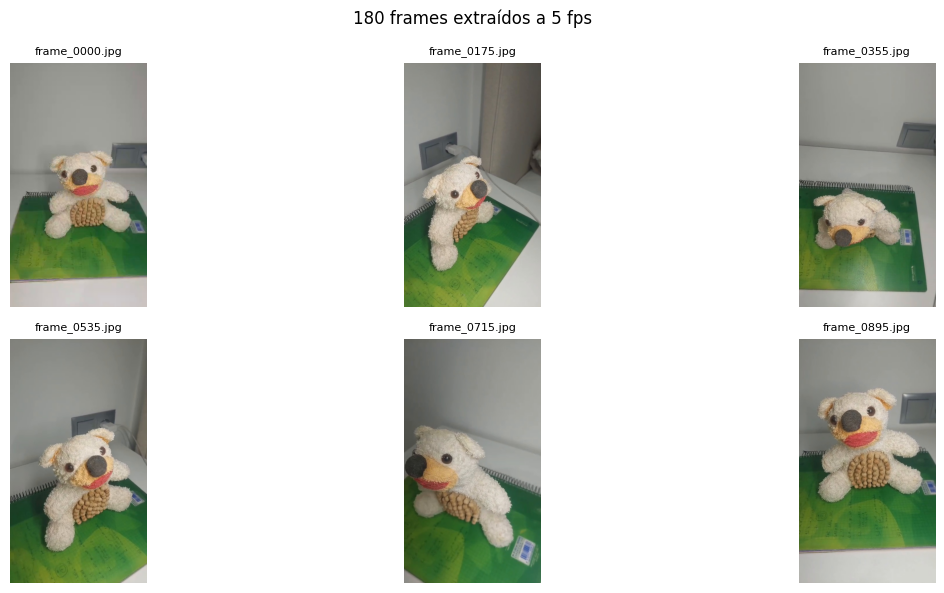

In [19]:
# Mostrar una selección de frames extraídos
files = sorted(os.listdir(FRAMES))
indices = np.linspace(0, len(files)-1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, i in zip(axes.flat, indices):
    img = cv2.cvtColor(cv2.imread(f'{FRAMES}/{files[i]}'), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(files[i], fontsize=8)
    ax.axis('off')
plt.suptitle(f'{len(files)} frames extraídos a {FPS_OUT} fps')
plt.tight_layout()

## 2. Pipeline COLMAP

Los siguientes comandos se ejecutan en terminal. COLMAP trabaja en tres etapas: extracción de características SIFT, emparejamiento exhaustivo entre todos los pares de imágenes y reconstrucción incremental (mapper).

```bash
# Extracción de características SIFT
colmap feature_extractor \
    --database_path database.db \
    --image_path frames \
    --ImageReader.single_camera 1 \
    --SiftExtraction.peak_threshold 0.003

# Emparejamiento exhaustivo entre todos los pares
colmap exhaustive_matcher \
    --database_path database.db

# Reconstrucción 3D incremental
colmap mapper \
    --database_path database.db \
    --image_path frames \
    --output_path sparse \
    --Mapper.init_min_num_inliers 10 \
    --Mapper.init_max_reg_trials 200
```

**Parámetros clave:**
- `--ImageReader.single_camera 1`: todos los frames proceden de la misma cámara (vídeo), por lo que comparten parámetros intrínsecos.
- `--SiftExtraction.peak_threshold 0.003`: umbral más bajo que el valor por defecto para detectar más puntos en superficies con textura suave.
- `--Mapper.init_max_reg_trials 200`: más intentos de inicialización para escenas con movimiento mayoritariamente rotacional.

## 3. Resultado COLMAP

El mapper genera una **nube de puntos dispersa** (*sparse reconstruction*) con las posiciones 3D de los puntos SIFT y las poses de cada cámara. Las cámaras (triángulos rojos) forman un arco alrededor del objeto, coherente con el movimiento de captura.

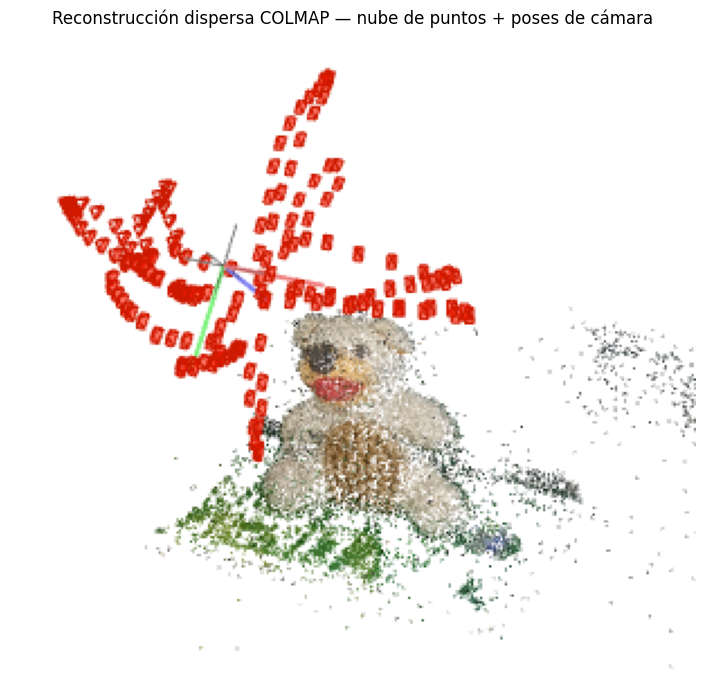

In [22]:
from IPython.display import Image as IPImage

fig, ax = plt.subplots(figsize=(10, 7))
img = cv2.cvtColor(cv2.imread('colmap-oso.png'), cv2.COLOR_BGR2RGB)
ax.imshow(img)
ax.set_title('Reconstrucción dispersa COLMAP — nube de puntos + poses de cámara')
ax.axis('off')
plt.tight_layout()

## 4. Comparación con vggt

**vggt** se ejecutó en Google Colab (GPU T4) clonando el repositorio oficial y lanzando el demo Gradio. Se suben únicamente **15 frames** representativos — con más imágenes el transformer se queda sin VRAM (CUDA out of memory con 180 frames en una T4 de 15 GB).

A diferencia de COLMAP, vggt no necesita emparejamiento explícito ni iteraciones: el transformer infiere directamente las poses de cámara y un mapa de profundidad denso en menos de un segundo. El modelo 3D exportado se guarda en `model-vggt-oso.glb`.

```bash
# En Google Colab (GPU T4)
!git clone https://github.com/facebookresearch/vggt.git
%cd vggt
!pip install -r requirements.txt -q
!pip install trimesh -q
!python demo_gradio.py
```

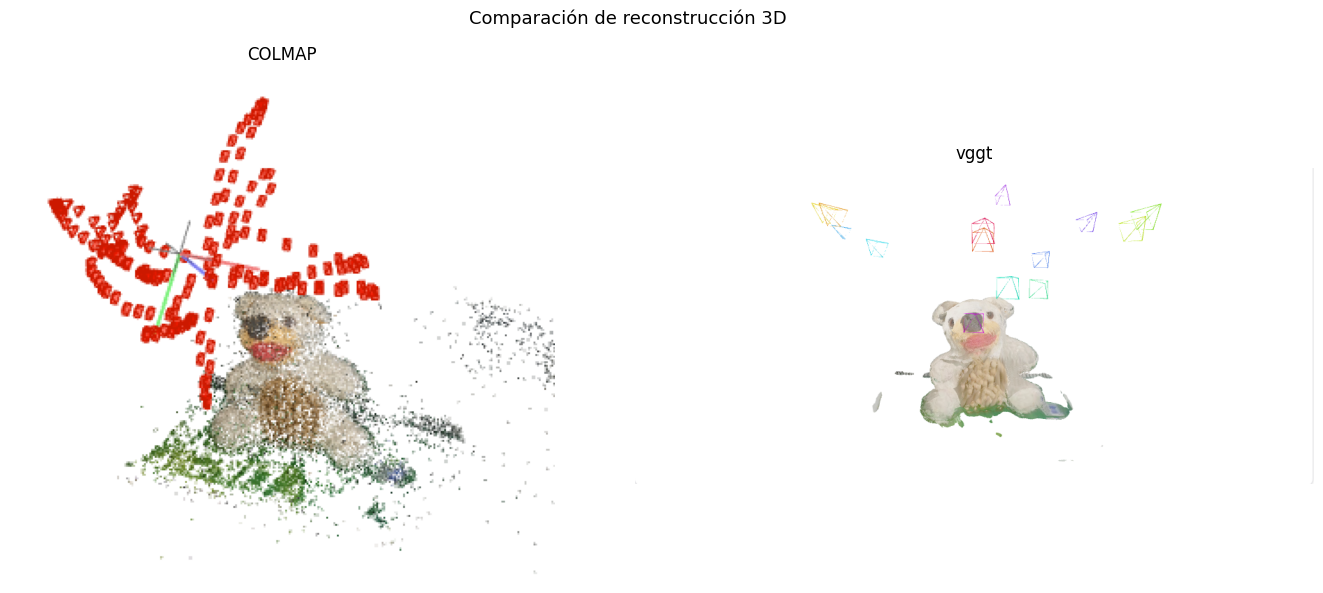

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colmap_img = cv2.cvtColor(cv2.imread('colmap-oso.png'), cv2.COLOR_BGR2RGB)
vggt_img   = cv2.cvtColor(cv2.imread('vggt-oso.png'),   cv2.COLOR_BGR2RGB)
axes[0].imshow(colmap_img); axes[0].set_title('COLMAP'); axes[0].axis('off')
axes[1].imshow(vggt_img);   axes[1].set_title('vggt');    axes[1].axis('off')
plt.suptitle('Comparación de reconstrucción 3D', fontsize=13)
plt.tight_layout()

## 5. Conclusiones

El resultado más llamativo es que **vggt con solo 15 imágenes produce una reconstrucción notablemente mejor que COLMAP con 180 imágenes**. COLMAP no logra conectar todos los submodelos en uno coherente (el mapper divide la escena en grupos desconectados), mientras que vggt reconstruye correctamente la forma del objeto en una única pasada.

Esto se explica por las diferencias fundamentales entre ambos enfoques:

| Aspecto | COLMAP | vggt |
|---------|--------|------|
| Enfoque | Pipeline clásico (SIFT + RANSAC + bundle adjustment) | Transformer end-to-end |
| Imágenes usadas | 180 frames | 15 frames |
| Velocidad | ~15 min en CPU | <60 segundo en GPU |
| Densidad | Nube dispersa (sparse) | Mapa de profundidad denso |
| GPU requerida | No | Recomendada (se usa T4 de colab) |
| Textura necesaria | Sí — SIFT falla en superficies lisas o repetitivas | No — usa priors visuales aprendidos |
| Modelo exportado | Nube de puntos `.bin` | Malla 3D `.glb` |

COLMAP sigue siendo útil cuando no se dispone de GPU o se necesita un pipeline completamente reproducible y explicable. vggt es superior en calidad y velocidad cuando se tiene acceso a GPU, especialmente en objetos con poca textura superficial donde SIFT no encuentra correspondencias fiables.